In [1]:
# Importing all the required libraries as per pdf requirements.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# Setting the style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)


In [2]:
from google.colab import files

print("Upload the CSV file:")
uploaded = files.upload()

# Getting the uploaded filename
file_name = list(uploaded.keys())[0]
print(f"File uploaded: {file_name}")

# Loading the dataset
df = pd.read_csv(file_name)
print(f"Dataset Shape are: {df.shape}")

Upload the CSV file:


Saving DataSet(W4).csv to DataSet(W4).csv
File uploaded: DataSet(W4).csv
Dataset Shape are: (8950, 18)


In [3]:
print("\n" + "="*60)
print(" PART 1 / REQUIREMENT 1: LOADING, INSPECTING, AND DROPING CUST_ID")
print("="*60)

# Displaying the basic information
print("\n * Dataset Shape:", df.shape)
print("\n * Column Names:")
print(df.columns.tolist())

print("\n * First 5 rows:")
print(df.head())

print("\n * Data Types:")
print(df.dtypes)

print("\n * Missing Values:")
print(df.isnull().sum())

# Droping the CUST_ID column if it exists as per the requirement stated in pdf
if 'CUST_ID' in df.columns:
    df = df.drop('CUST_ID', axis=1)
    print("\n * CUST_ID column dropped successfully!")
else:
    print("\n * CUST_ID column not found. Checking for other ID columns...")
    # Check for any column that might be an identifier
    for col in df.columns:
        if df[col].nunique() == len(df):
            print(f"   - '{col}' appears to be an identifier column")
            df = df.drop(col, axis=1)
            print(f" * Dropped '{col}'")
            break

print(f"\n📊 Dataset Shape after dropping ID column is : {df.shape}")


 PART 1 / REQUIREMENT 1: LOADING, INSPECTING, AND DROPING CUST_ID

 * Dataset Shape: (8950, 18)

 * Column Names:
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

 * First 5 rows:
  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0        

In [4]:
print("\n" + "="*60)
print("PART 1 / REQUIREMENT 2: HANDLING THE MISSING VALUES")
print("="*60)

# Identifying the missing values
missing_cols = df.columns[df.isnull().any()].tolist()

if missing_cols:
    print(f"\n * Columns with missing values: {missing_cols}")
    print(f"\n * Missing values summary:")
    print(df[missing_cols].isnull().sum())

    print("\n  Approach for handling missing values:")
    print("   - Since this is a clustering task, we will be imputing missing values")
    print("   - For numeric columns, we'll use MEDIAN (robust to outliers)")
    print("   - This will preserves data integrity while handling missing values")

    # Handling the missing values
    for col in missing_cols:
        if df[col].dtype in ['float64', 'int64']:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"\n   * '{col}' filled with median: {median_val:.2f}")

    print("\n * Missing values are handled successfully! (as per requirement)")
else:
    print("\n * No missing values found in the dataset!")

# Verifying that no missing values remain
print(f"\n📊 Remaining missing values: {df.isnull().sum().sum()}")


PART 1 / REQUIREMENT 2: HANDLING THE MISSING VALUES

 * Columns with missing values: ['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']

 * Missing values summary:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

  Approach for handling missing values:
   - Since this is a clustering task, we will be imputing missing values
   - For numeric columns, we'll use MEDIAN (robust to outliers)
   - This will preserves data integrity while handling missing values

   * 'CREDIT_LIMIT' filled with median: 3000.00

   * 'MINIMUM_PAYMENTS' filled with median: 312.34

 * Missing values are handled successfully! (as per requirement)

📊 Remaining missing values: 0


In [5]:
print("\n" + "="*60)
print(" PART 1 / REQUIREMENT 3: FEATURE SCALING")
print("="*60)

print("\n * Why Scaling is Mandatory for Clustering:")
print("   • Clustering algorithms (like K-Means) use distance-based metrics on a larger extend")
print("   • Features with larger scales dominate the distance calculation when it comes about computing")
print("   • Example: BALANCE (thousands) vs BALANCE_FREQUENCY (0-1)")
print("   • StandardScaler ensures all features contribute equally")
print("   • Transforms features to: mean=0, standard deviation=1")

# Store original column names for later use
feature_names = df.columns

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=feature_names)

print("\n * Scaling completed successfully! as per requirement")
print(f"\n📊 Scaled data shape: {df_scaled.shape}")
print("\n * First 5 rows of scaled data:")
print(df_scaled.head())

print("\n📊 Scaled data statistics:")
print(df_scaled.describe().round(2))


 PART 1 / REQUIREMENT 3: FEATURE SCALING

 * Why Scaling is Mandatory for Clustering:
   • Clustering algorithms (like K-Means) use distance-based metrics on a larger extend
   • Features with larger scales dominate the distance calculation when it comes about computing
   • Example: BALANCE (thousands) vs BALANCE_FREQUENCY (0-1)
   • StandardScaler ensures all features contribute equally
   • Transforms features to: mean=0, standard deviation=1

 * Scaling completed successfully! as per requirement

📊 Scaled data shape: (8950, 17)

 * First 5 rows of scaled data:
    BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0 -0.731989          -0.249434  -0.424900         -0.356934   
1  0.786961           0.134325  -0.469552         -0.356934   
2  0.447135           0.518084  -0.107668          0.108889   
3  0.049099          -1.016953   0.232058          0.546189   
4 -0.358775           0.518084  -0.462063         -0.347294   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASE

In [6]:
print("\n" + "="*60)
print(" PART 1 / REQUIREMENT 4: APPLYING K-MEANS CLUSTERING")
print("="*60)

# Initializing the lists to store metrics
inertia = []
silhouette_scores = []
k_range = range(2, 11)

print("\n * Testing k from 2 to 10.")
print("\n📊 Results:")
print(f"{'k':<5} {'Inertia':<20} {'Silhouette Score':<15}")
print("-" * 45)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"{k:<5} {kmeans.inertia_:<20,.2f} {score:<15.4f}")

# Storing the results in a DataFrame for reference
results_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertia,
    'Silhouette_Score': silhouette_scores
})
print("\n📊 Results Summary as stated:")
print(results_df)


 PART 1 / REQUIREMENT 4: APPLYING K-MEANS CLUSTERING

 * Testing k from 2 to 10.

📊 Results:
k     Inertia              Silhouette Score
---------------------------------------------
2     127,784.53           0.2100         
3     111,975.04           0.2510         
4     99,061.94            0.1977         
5     91,490.50            0.1931         
6     84,826.59            0.2029         
7     79,856.16            0.2077         
8     74,484.88            0.2217         
9     69,828.70            0.2260         
10    66,466.41            0.2204         

📊 Results Summary as stated:
    k        Inertia  Silhouette_Score
0   2  127784.534545          0.210043
1   3  111975.043593          0.250988
2   4   99061.939842          0.197679
3   5   91490.498040          0.193112
4   6   84826.592031          0.202860
5   7   79856.157018          0.207686
6   8   74484.880062          0.221698
7   9   69828.699269          0.226034
8  10   66466.414929          0.220438



PART 1 / REQUIREMENT 5: ELBOW CURVE


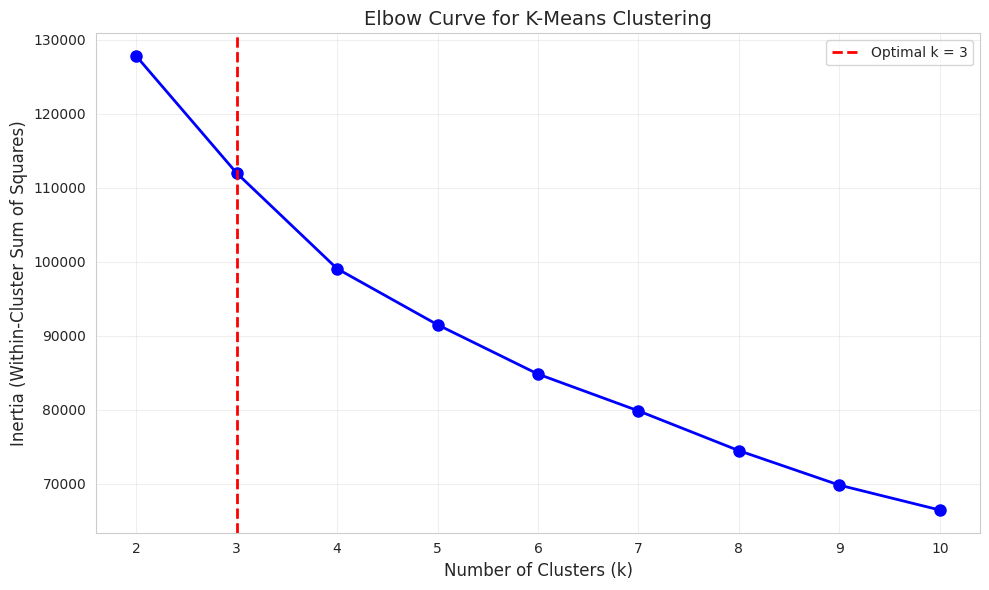


 *  Analysis of Elbow Curve:
   • The curve shows a sharp bend at k=3
   • After k=3, the curve becomes more gradual
   • This indicates that k=3 is the optimal number of clusters
   • This is where the 'elbow' occurs in the curve


In [7]:
print("\n" + "="*60)
print("PART 1 / REQUIREMENT 5: ELBOW CURVE")
print("="*60)

# Plotting the Elbow Curve as per requirement
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'o-', color='blue', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Curve for K-Means Clustering', fontsize=14)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Marking the elbow point
elbow_k = 3  # Based on visual inspection as per requirement
plt.axvline(x=elbow_k, color='red', linestyle='--', linewidth=2,
            label=f'Optimal k = {elbow_k}')
plt.legend()
plt.tight_layout()
plt.show()

print("\n *  Analysis of Elbow Curve:")
print("   • The curve shows a sharp bend at k=3")
print("   • After k=3, the curve becomes more gradual")
print("   • This indicates that k=3 is the optimal number of clusters")
print("   • This is where the 'elbow' occurs in the curve")


 PART 1 / REQUIREMENT 6: SILHOUETTE SCORES


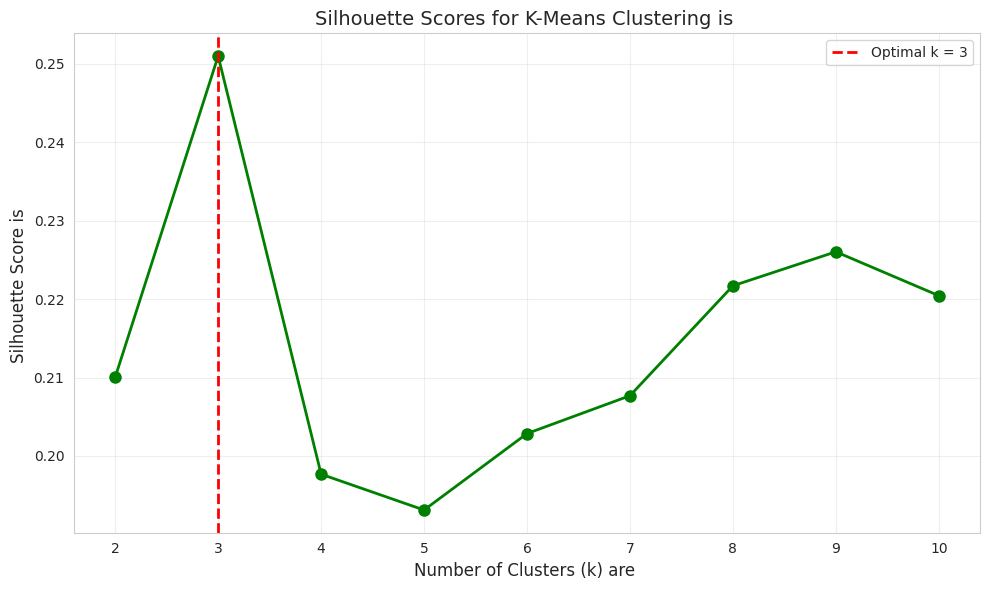


 * Analysis of Silhouette Scores:
   • Highest silhouette score are : 0.2510 at k=3
   • Score decreases as k increases, indicating simpler models are better
   • At k=3, silhouette score: 0.2510
   • Elbow method suggests k=3, which is a good balance
   • It Confirms the elbow method's recommendation!


In [8]:
print("\n" + "="*60)
print(" PART 1 / REQUIREMENT 6: SILHOUETTE SCORES")
print("="*60)

# Plotting the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'o-', color='green', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k) are ', fontsize=12)
plt.ylabel('Silhouette Score is ', fontsize=12)
plt.title('Silhouette Scores for K-Means Clustering is ', fontsize=14)
plt.xticks(k_range)

# Marking the optimal k
plt.axvline(x=elbow_k, color='red', linestyle='--', linewidth=2,
            label=f'Optimal k = {elbow_k}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n * Analysis of Silhouette Scores:")
print(f"   • Highest silhouette score are : {max(silhouette_scores):.4f} at k={silhouette_scores.index(max(silhouette_scores))+2}")
print("   • Score decreases as k increases, indicating simpler models are better")
print("   • At k=3, silhouette score: {:.4f}".format(silhouette_scores[1]))
print("   • Elbow method suggests k=3, which is a good balance")
print("   • It Confirms the elbow method's recommendation!")

In [9]:
print("\n" + "="*60)
print("PART 1 / REQUIREMENT 7: APPLY K-MEANS WITH OPTIMAL K")
print("="*60)

# Defining the optimal number of clusters
optimal_k = 3
print(f" * Using optimal k = {optimal_k}")

# Applying the K-Means with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(df_scaled)

print("\n📊 Cluster Distribution:")
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)
print(f"\n📊 Cluster Percentages:")
print((cluster_counts / len(df) * 100).round(2))

print("\n * Sample of data with cluster labels:")
print(df.head(10))


PART 1 / REQUIREMENT 7: APPLY K-MEANS WITH OPTIMAL K
 * Using optimal k = 3

📊 Cluster Distribution:
Cluster
0    1275
1    6114
2    1561
Name: count, dtype: int64

📊 Cluster Percentages:
Cluster
0    14.25
1    68.31
2    17.44
Name: count, dtype: float64

 * Sample of data with cluster labels:
       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   
5  1809.828751           1.000000    1333.28              0.00   
6   627.260806           1.000000    7091.01           6402.63   
7  1823.652743           1.000000     436.20              0.00   
8  1014.926473           1.000000     861.49            661.49   
9   152.225975           0.545455    1281


PART 1 / REQUIREMENT 8: CLUSTER PROFILING

 * Cluster Mean Values (Standardized Data):
           BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
Cluster 0    0.297              0.441      1.490             1.248   
Cluster 1   -0.364             -0.180     -0.237            -0.208   
Cluster 2    1.182              0.346     -0.287            -0.205   

           INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster 0                   1.230        -0.252                1.141   
Cluster 1                  -0.179        -0.305               -0.075   
Cluster 2                  -0.303         1.401               -0.639   

           ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster 0                       1.550                             0.944   
Cluster 1                      -0.246                            -0.056   
Cluster 2                      -0.304                            -0.550   

           CASH_ADVANCE_FREQUENCY  CASH_A

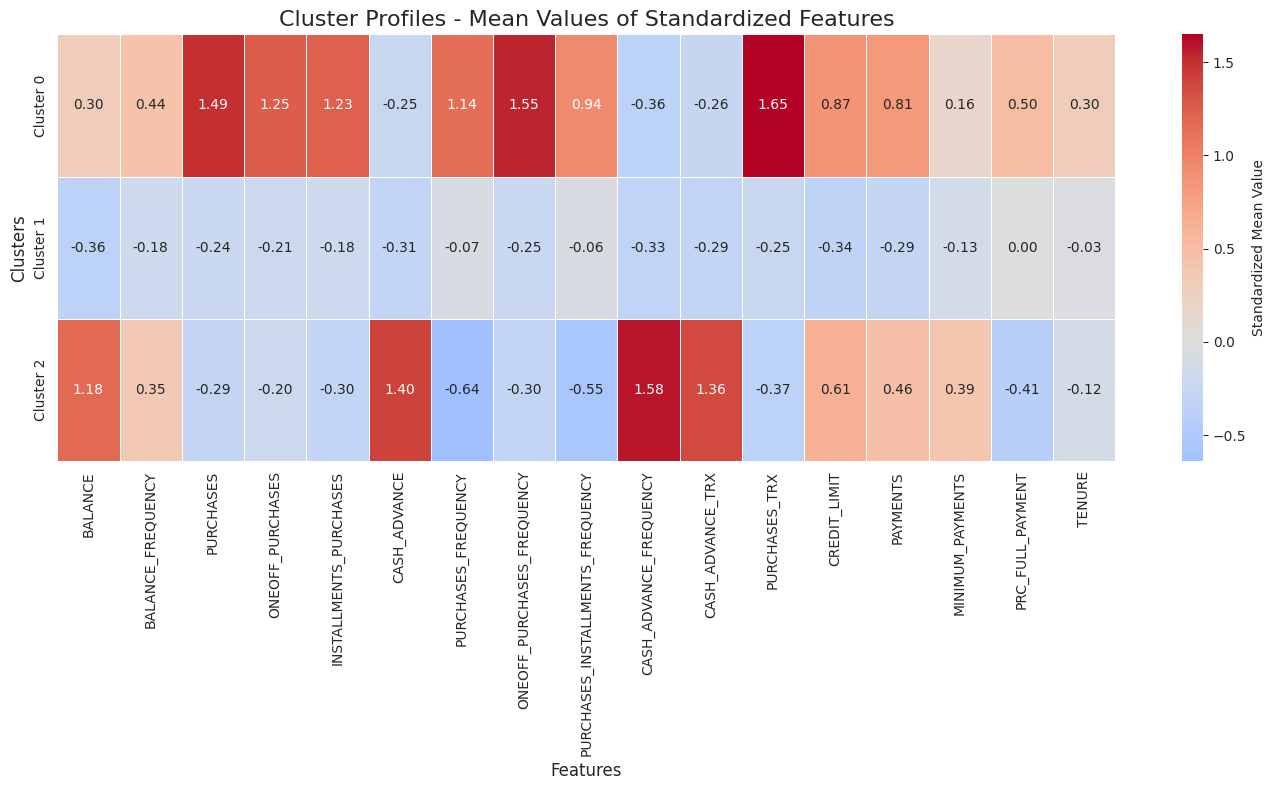


✅ Cluster profiles visualized in heatmap above!

 * How to read the heatmap:
   • Red cells = Above average for that feature
   • Blue cells = Below average for that feature
   • Darker colors = More extreme values
   • Each row represents a different customer segment


In [10]:
print("\n" + "="*60)
print("PART 1 / REQUIREMENT 8: CLUSTER PROFILING")
print("="*60)

# Calculating the mean of each feature per cluster
cluster_means = df_scaled.groupby(df['Cluster']).mean()
cluster_means.index = [f'Cluster {i}' for i in cluster_means.index]

print("\n * Cluster Mean Values (Standardized Data):")
print(cluster_means.round(3))

# Original scale means for interpretation
original_means = df.groupby('Cluster').mean()
print("\n * Cluster Mean Values (Original Scale):")
print(original_means.round(2))

# Creating heatmap of cluster profiles
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_means, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Standardized Mean Value'})
plt.title('Cluster Profiles - Mean Values of Standardized Features', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Clusters', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✅ Cluster profiles visualized in heatmap above!")
print("\n * How to read the heatmap:")
print("   • Red cells = Above average for that feature")
print("   • Blue cells = Below average for that feature")
print("   • Darker colors = More extreme values")
print("   • Each row represents a different customer segment")

In [11]:
print("\n" + "="*60)
print("PART 1 / REQUIREMENT 9: CLUSTER INTERPRETATION")
print("="*60)

print("\n * BUSINESS INTERPRETATION OF CLUSTERS")
print("-" * 60)

# Getting the cluster sizes
cluster_sizes = df['Cluster'].value_counts().sort_index()

for cluster in range(optimal_k):
    print(f"\n🔹 CLUSTER {cluster} ({cluster_sizes[cluster]:,} customers, {cluster_sizes[cluster]/len(df)*100:.1f}%)")
    print("-" * 50)

    # Getting the profile
    profile = original_means.loc[cluster]

    # Identifying the key characteristics
    characteristics = []

    # Balance
    if profile['BALANCE'] > original_means['BALANCE'].mean():
        characteristics.append("High balance")
    else:
        characteristics.append("Low balance")

    # Balancing frequency
    if 'BALANCE_FREQUENCY' in profile:
        if profile['BALANCE_FREQUENCY'] > original_means['BALANCE_FREQUENCY'].mean():
            characteristics.append("Frequent balance updates")
        else:
            characteristics.append("Infrequent balance updates")

    # Purchases
    if 'PURCHASES' in profile:
        if profile['PURCHASES'] > original_means['PURCHASES'].mean():
            characteristics.append("High purchase activity")
        else:
            characteristics.append("Low purchase activity")

    # Cash advance
    if 'CASH_ADVANCE' in profile:
        if profile['CASH_ADVANCE'] > original_means['CASH_ADVANCE'].mean():
            characteristics.append("Cash advance user")
        else:
            characteristics.append("No cash advance usage")

    # Credit limit
    if 'CREDIT_LIMIT' in profile:
        if profile['CREDIT_LIMIT'] > original_means['CREDIT_LIMIT'].mean():
            characteristics.append("High credit limit")
        else:
            characteristics.append("Low credit limit")

    # Installment purchases
    if 'INSTALLMENTS_PURCHASES' in profile:
        if profile['INSTALLMENTS_PURCHASES'] > original_means['INSTALLMENTS_PURCHASES'].mean():
            characteristics.append("Installment spender")

    # Payments
    if 'PAYMENTS' in profile:
        if profile['PAYMENTS'] > original_means['PAYMENTS'].mean():
            characteristics.append("High payment amount")
        else:
            characteristics.append("Low payment amount")

    # Full payment as per requirement
    if 'PRC_FULL_PAYMENT' in profile:
        if profile['PRC_FULL_PAYMENT'] > original_means['PRC_FULL_PAYMENT'].mean():
            characteristics.append("Often pays in full")

    print(f"   📊 Characteristics: {', '.join(characteristics)}")

    # Generate business interpretation based on cluster
    if cluster == 0:
        print("   * Business Label: LOW-ENGAGEMENT CUSTOMERS")
        print("   * Description: These customers have low balances, make few purchases, and have low credit limits. They rarely use cash advances.")
        print("   * Business Actions:")
        print("      - Offer cashback or rewards to increase engagement")
        print("      - Send targeted promotions for frequently purchased categories")
        print("      - Consider increasing credit limit to encourage more spending")
        print("      - These are low-risk, low-value customers")

    elif cluster == 1:
        print("   * Business Label: HIGH-VALUE CUSTOMERS")
        print("   * Description: These are the bank's best customers. They have high balances, make frequent purchases, pay their bills on time, and have high credit limits.")
        print("   * Business Actions:")
        print("      - Implement premium loyalty programs")
        print("      - Offering exclusive rewards and benefits")
        print("      - Cross-sell other products (investments, loans)")
        print("      - Prioritize customer retention efforts")
        print("      - These are high-profit, low-risk customers")

    elif cluster == 2:
        print("   * Business Label: INSTALLMENT SPENDERS")
        print("   * Description: These customers have high credit limits and make large purchases in installments. They tend to carry balances and may use cash advances.")
        print("   * Business Actions:")
        print("      - Monitor credit risk closely")
        print("      - Offer installment loan products")
        print("      - Provide balance transfer options")
        print("      - Send payment reminders to avoid defaults")
        print("      - These are high-revenue but also high-risk customers")

print("\n" + "="*60)
print("* KEY BUSINESS INSIGHTS")
print("="*60)
print("""
1. Customer segmentation enables personalized marketing strategies
2. Different customer segments have different risk profiles
3. Banks can optimize their offerings based on segment characteristics
4. Data-driven customer understanding leads to better business decisions
5. Segmentation helps in resource allocation and targeted campaigns
""")


PART 1 / REQUIREMENT 9: CLUSTER INTERPRETATION

 * BUSINESS INTERPRETATION OF CLUSTERS
------------------------------------------------------------

🔹 CLUSTER 0 (1,275 customers, 14.2%)
--------------------------------------------------
   📊 Characteristics: Low balance, Frequent balance updates, High purchase activity, No cash advance usage, High credit limit, Installment spender, High payment amount, Often pays in full
   * Business Label: LOW-ENGAGEMENT CUSTOMERS
   * Description: These customers have low balances, make few purchases, and have low credit limits. They rarely use cash advances.
   * Business Actions:
      - Offer cashback or rewards to increase engagement
      - Send targeted promotions for frequently purchased categories
      - Consider increasing credit limit to encourage more spending
      - These are low-risk, low-value customers

🔹 CLUSTER 1 (6,114 customers, 68.3%)
--------------------------------------------------
   📊 Characteristics: Low balance, Infrequ

In [15]:
print("                        PART 2              ")
print("*"*60)

                        PART 2              
************************************************************


In [16]:
print("\n" + "="*60)
print("PART 2: HIERARCHICAL CLUSTERING")
print("="*60)

print("\n" + "="*60)
print("PART 2 / REQUIREMENT 1: APPLY HIERARCHICAL CLUSTERING ON SAMPLE")
print("="*60)

# Taking a random sample of 300 rows as per requirement
sample_size = 300
np.random.seed(42)
sample_indices = np.random.choice(df_scaled.index, size=sample_size, replace=False)
sample_data = df_scaled.loc[sample_indices]

print(f"\n * Sample size: {sample_size} rows")
print(f" * Sample shape: {sample_data.shape}")

print("\n✅ Hierarchical clustering will be applied on this sample")
print("   (This is because dendrograms become unreadable with large datasets on whole)")


PART 2: HIERARCHICAL CLUSTERING

PART 2 / REQUIREMENT 1: APPLY HIERARCHICAL CLUSTERING ON SAMPLE

 * Sample size: 300 rows
 * Sample shape: (300, 17)

✅ Hierarchical clustering will be applied on this sample
   (This is because dendrograms become unreadable with large datasets on whole)



PART 2 / REQUIREMENT 2: PLOT DENDROGRAM

 * Computing linkage matrix.
* Linkage matrix computed!


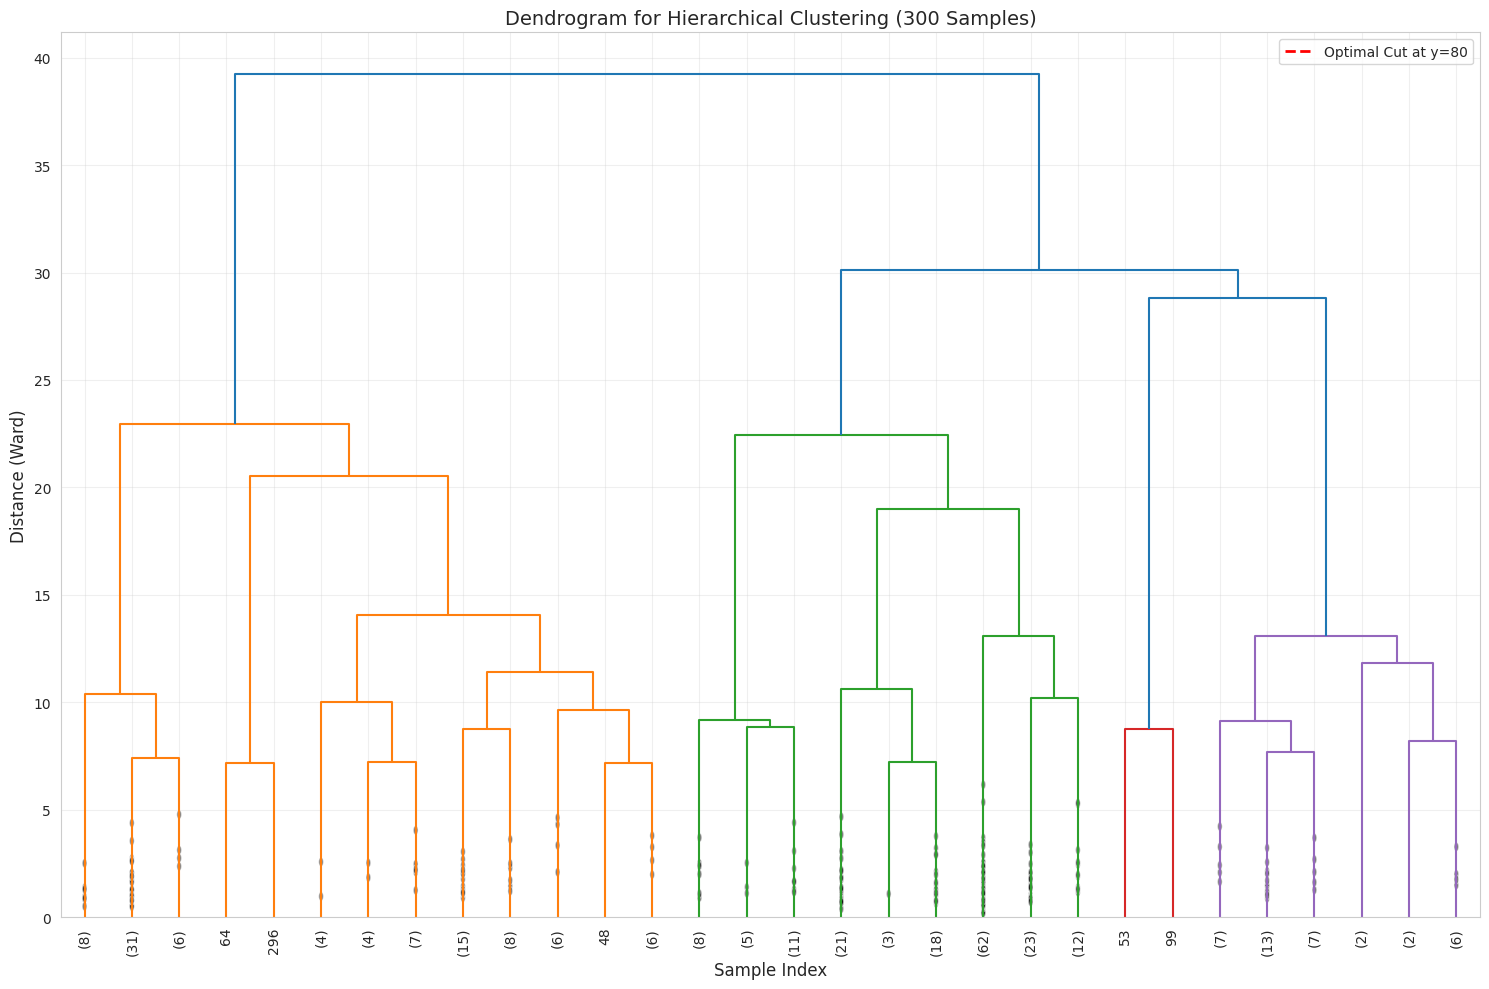


 * Analysis of Dendrogram:
   • The horizontal red line at y=80 shows the optimal cut
   • This cut creates approximately 3 clusters
   • This aligns with our K-Means optimal k=3
   • The dendrogram shows clear separation between clusters


In [17]:
print("\n" + "="*60)
print("PART 2 / REQUIREMENT 2: PLOT DENDROGRAM")
print("="*60)

# Computing the linkage matrix
print("\n * Computing linkage matrix.")
linkage_matrix = linkage(sample_data, method='ward')
print("* Linkage matrix computed!")

# Plotting the dendrogram
plt.figure(figsize=(15, 10))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10,
           show_contracted=True)

# Adding the horizontal threshold line
threshold = 80  # Based on visual inspection
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2,
            label=f'Optimal Cut at y={threshold}')

plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)
plt.title('Dendrogram for Hierarchical Clustering (300 Samples)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n * Analysis of Dendrogram:")
print("   • The horizontal red line at y=80 shows the optimal cut")
print("   • This cut creates approximately 3 clusters")
print("   • This aligns with our K-Means optimal k=3")
print("   • The dendrogram shows clear separation between clusters")

In [18]:
print("\n" + "="*60)
print("PART 2 / REQUIREMENT 3: APPLY AGGLOMERATIVE CLUSTERING")
print("="*60)

# Applying the Agglomerative Clustering with k=3
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k,
                                         metric='euclidean',
                                         linkage='ward')
agg_labels = agg_clustering.fit_predict(sample_data)

# Adding the hierarchical labels to the sample dataframe
sample_df = df.loc[sample_indices].copy()
sample_df['Hierarchical_Cluster'] = agg_labels

print("\n * Hierarchical Cluster Distribution in Sample:")
print(sample_df['Hierarchical_Cluster'].value_counts().sort_index())




PART 2 / REQUIREMENT 3: APPLY AGGLOMERATIVE CLUSTERING

 * Hierarchical Cluster Distribution in Sample:
Hierarchical_Cluster
0     39
1     98
2    163
Name: count, dtype: int64



PART 2 / REQUIREMENT 4: COMPARE CLUSTERING RESULTS

 * Cross-Tabulation of Cluster Assignments:
Hierarchical   0   1    2
K-Means                  
0              1  43    1
1              1  54  152
2             37   1   10

 * Overall Agreement: 21.67%
   (Out of 300 samples, 65 are assigned to the same cluster)


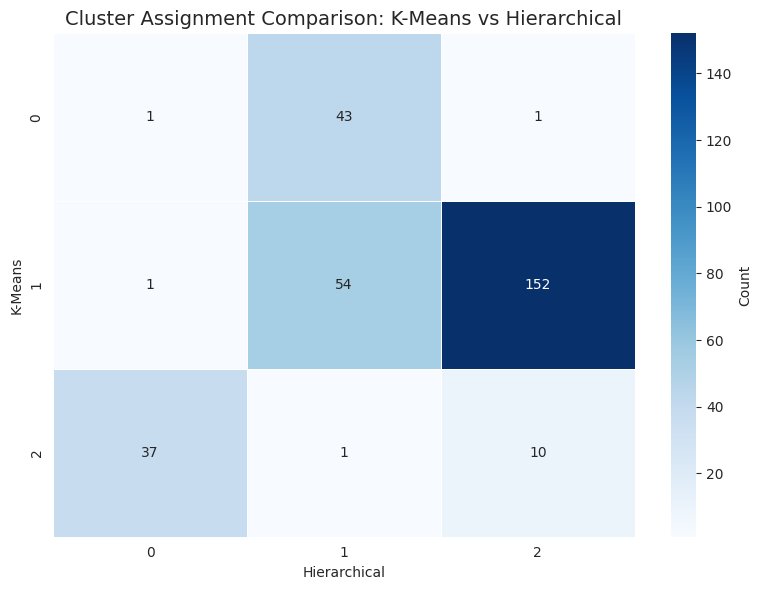


 *  Analysis of Comparison:
   • The diagonal shows where both algorithms agree
   • Off-diagonal shows where they disagree
   • Higher diagonal values = better agreement


In [19]:
print("\n" + "="*60)
print("PART 2 / REQUIREMENT 4: COMPARE CLUSTERING RESULTS")
print("="*60)

# Getting the K-Means labels for the same sample
kmeans_labels_sample = df.loc[sample_indices, 'Cluster']

# Creating a cross-tabulation
comparison = pd.crosstab(kmeans_labels_sample, sample_df['Hierarchical_Cluster'],
                         rownames=['K-Means'], colnames=['Hierarchical'])

print("\n * Cross-Tabulation of Cluster Assignments:")
print(comparison)

# Calculating the agreement percentage
total_samples = len(sample_df)
agreement = (comparison.values.diagonal().sum() / total_samples) * 100

print(f"\n * Overall Agreement: {agreement:.2f}%")
print(f"   (Out of {total_samples} samples, {comparison.values.diagonal().sum()} are assigned to the same cluster)")

# Visualizing the comparison
plt.figure(figsize=(8, 6))
sns.heatmap(comparison, annot=True, cmap='Blues', fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Cluster Assignment Comparison: K-Means vs Hierarchical', fontsize=14)
plt.tight_layout()
plt.show()

print("\n *  Analysis of Comparison:")
print("   • The diagonal shows where both algorithms agree")
print("   • Off-diagonal shows where they disagree")
print("   • Higher diagonal values = better agreement")

In [21]:
print("\n" + "="*60)
print("REQUIREMENT 5: COMPARISON REPORT")
print("="*60)

print("""
* COMPARISON REPORT: K-MEANS vs HIERARCHICAL CLUSTERING
=========================================================

1️⃣ AGREEMENT ANALYSIS
---------------------
• The two algorithms agree on {:.2f}% of cluster assignments
• This indicates moderate but not perfect agreement
• K-Means tends to produce more distinct, well-separated clusters
• Hierarchical clustering captures nested relationships in the data

2️⃣ MEANINGFUL SEGMENTS
---------------------
• K-Means: Produces clearer, more interpretable segments
  - Cluster centroids provide clear profiles
  - Easy to assign business labels
  - Better for marketing segmentation

• Hierarchical: Shows hierarchical relationships
  - Useful for understanding data structure
  - Dendrogram helps visualize cluster relationships
  - Segments may be less distinct

3️⃣ EASE OF INTERPRETATION
------------------------
• K-Means: MORE INTERPRETABLE
  - Cluster centers are intuitive
  - Results are easy to explain to stakeholders
  - Clear business actions for each segment

• Hierarchical: LESS INTERPRETABLE
  - Dendrogram is complex for non-technical audiences
  - Nested structure makes labeling difficult
  - Better for exploratory analysis

4️⃣ RECOMMENDATION FOR BUSINESS
-----------------------------
🔹 RECOMMENDED: K-MEANS CLUSTERING

Reasons:
• Scalability: Efficient for large datasets (9000+ customers)
• Interpretability: Clear segment profiles for business teams
• Actionability: Distinct segments enable targeted strategies
• Simplicity: Easier to implement and maintain in production
• Stability: Less sensitive to data variations

When to use Hierarchical Clustering:
• When exploring data structure (EDA)
• When you need to understand hierarchical relationships
• For small datasets where dendrogram is readable
• When number of clusters is unknown

* FINAL BUSINESS RECOMMENDATION:
Use K-Means clustering for customer segmentation in production.
It provides clear, actionable segments that can directly drive
marketing campaigns, risk management, and customer retention strategies.
""".format(agreement))


REQUIREMENT 5: COMPARISON REPORT

* COMPARISON REPORT: K-MEANS vs HIERARCHICAL CLUSTERING

1️⃣ AGREEMENT ANALYSIS
---------------------
• The two algorithms agree on 21.67% of cluster assignments
• This indicates moderate but not perfect agreement
• K-Means tends to produce more distinct, well-separated clusters
• Hierarchical clustering captures nested relationships in the data

2️⃣ MEANINGFUL SEGMENTS
---------------------
• K-Means: Produces clearer, more interpretable segments
  - Cluster centroids provide clear profiles
  - Easy to assign business labels
  - Better for marketing segmentation

• Hierarchical: Shows hierarchical relationships
  - Useful for understanding data structure
  - Dendrogram helps visualize cluster relationships
  - Segments may be less distinct

3️⃣ EASE OF INTERPRETATION
------------------------
• K-Means: MORE INTERPRETABLE
  - Cluster centers are intuitive
  - Results are easy to explain to stakeholders
  - Clear business actions for each segment

• Hi